## Importing libraries and formatting plots

In [ ]:
# Importing crap
# %load_ext autoreload
# %autoreload 2

import sys
sys.path.append('../../')

import numpy as np
import pandas as pd
import numexpr

import matplotlib.pyplot as plt
import matplotlib.patches as patches

import IRSMicroLensing.IRSFunctions as IRSF
import IRSMicroLensing.IRSCaustics as IRSC

import VBMicrolensing
import MulensModel as mm
import os

import csv

plt.rcParams['font.family'] = 'Times New Roman'
plt.rcParams['figure.titlesize'] = 20
plt.rcParams['figure.titleweight'] = 'bold'
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['axes.titlesize'] = 20
plt.rcParams['axes.labelsize'] = 20
plt.rcParams['figure.labelsize'] = 20
plt.rcParams['xtick.labelsize'] = 14
plt.rcParams['ytick.labelsize'] = 14
plt.rcParams['legend.title_fontsize'] = 16
plt.rcParams['legend.fontsize'] = 16
plt.rcParams['mathtext.fontset'] = 'cm'

## Reading in analysis output file

In [80]:
multipliers = [1e-1, 3e-1, 1e0, 3e0, 1e1]

df_list = []
thresholds_list = []
radius_list = []

one_e_4_list = []
three_e_4_list = []
one_e_3_list = []
three_e_3_list = []
one_e_2_list = []

for multiplier in multipliers:
    df = pd.read_csv(f'./Data Files/analysis_output_{multiplier:.0e}.csv')
    df_list.append(df)

    thresholds = np.array(df.columns[4:], dtype=float)
    thresholds_list.append(thresholds)

    radius = np.array(df['source_radius'].to_list())
    radius_list.append(radius)

    one_e_4 = np.array(df['1.1e-04'].to_list())
    one_e_4_list.append(one_e_4)

    three_e_4 = np.array(df['3.4e-04'].to_list())
    three_e_4_list.append(three_e_4)

    one_e_3 = np.array(df['1.0e-03'].to_list())
    one_e_3_list.append(one_e_3)

    three_e_3 = np.array(df['3.1e-03'].to_list())
    three_e_3_list.append(three_e_3)

    one_e_2 = np.array(df['1.1e-02'].to_list())
    one_e_2_list.append(one_e_2)

In [3]:
ss_str_1 = np.array(df_list[0]['s'].to_list(), dtype=str)
ss_1 = np.array([numexpr.evaluate(str(s)) for s in df_list[0]['s'].to_list()])
qs_1 = np.array(df_list[0]['q'].to_list())

ss_str_unique_1 = np.unique(ss_str_1)
ss_unique_1 = np.unique(ss_1)
qs_unique_1 = np.unique(qs_1)

print(ss_str_unique_1)
print(qs_unique_1)

['0.2' '0.3' '0.4' '0.5' '0.6' '0.7' '0.8' '0.9' '1.0' '1/0.2' '1/0.3'
 '1/0.4' '1/0.5' '1/0.6' '1/0.7' '1/0.8' '1/0.9']
[1.e-06 3.e-06 1.e-05 3.e-05 1.e-04 3.e-04 1.e-03]


## First, plotting fractional area as a function of source star radius for different thresholds

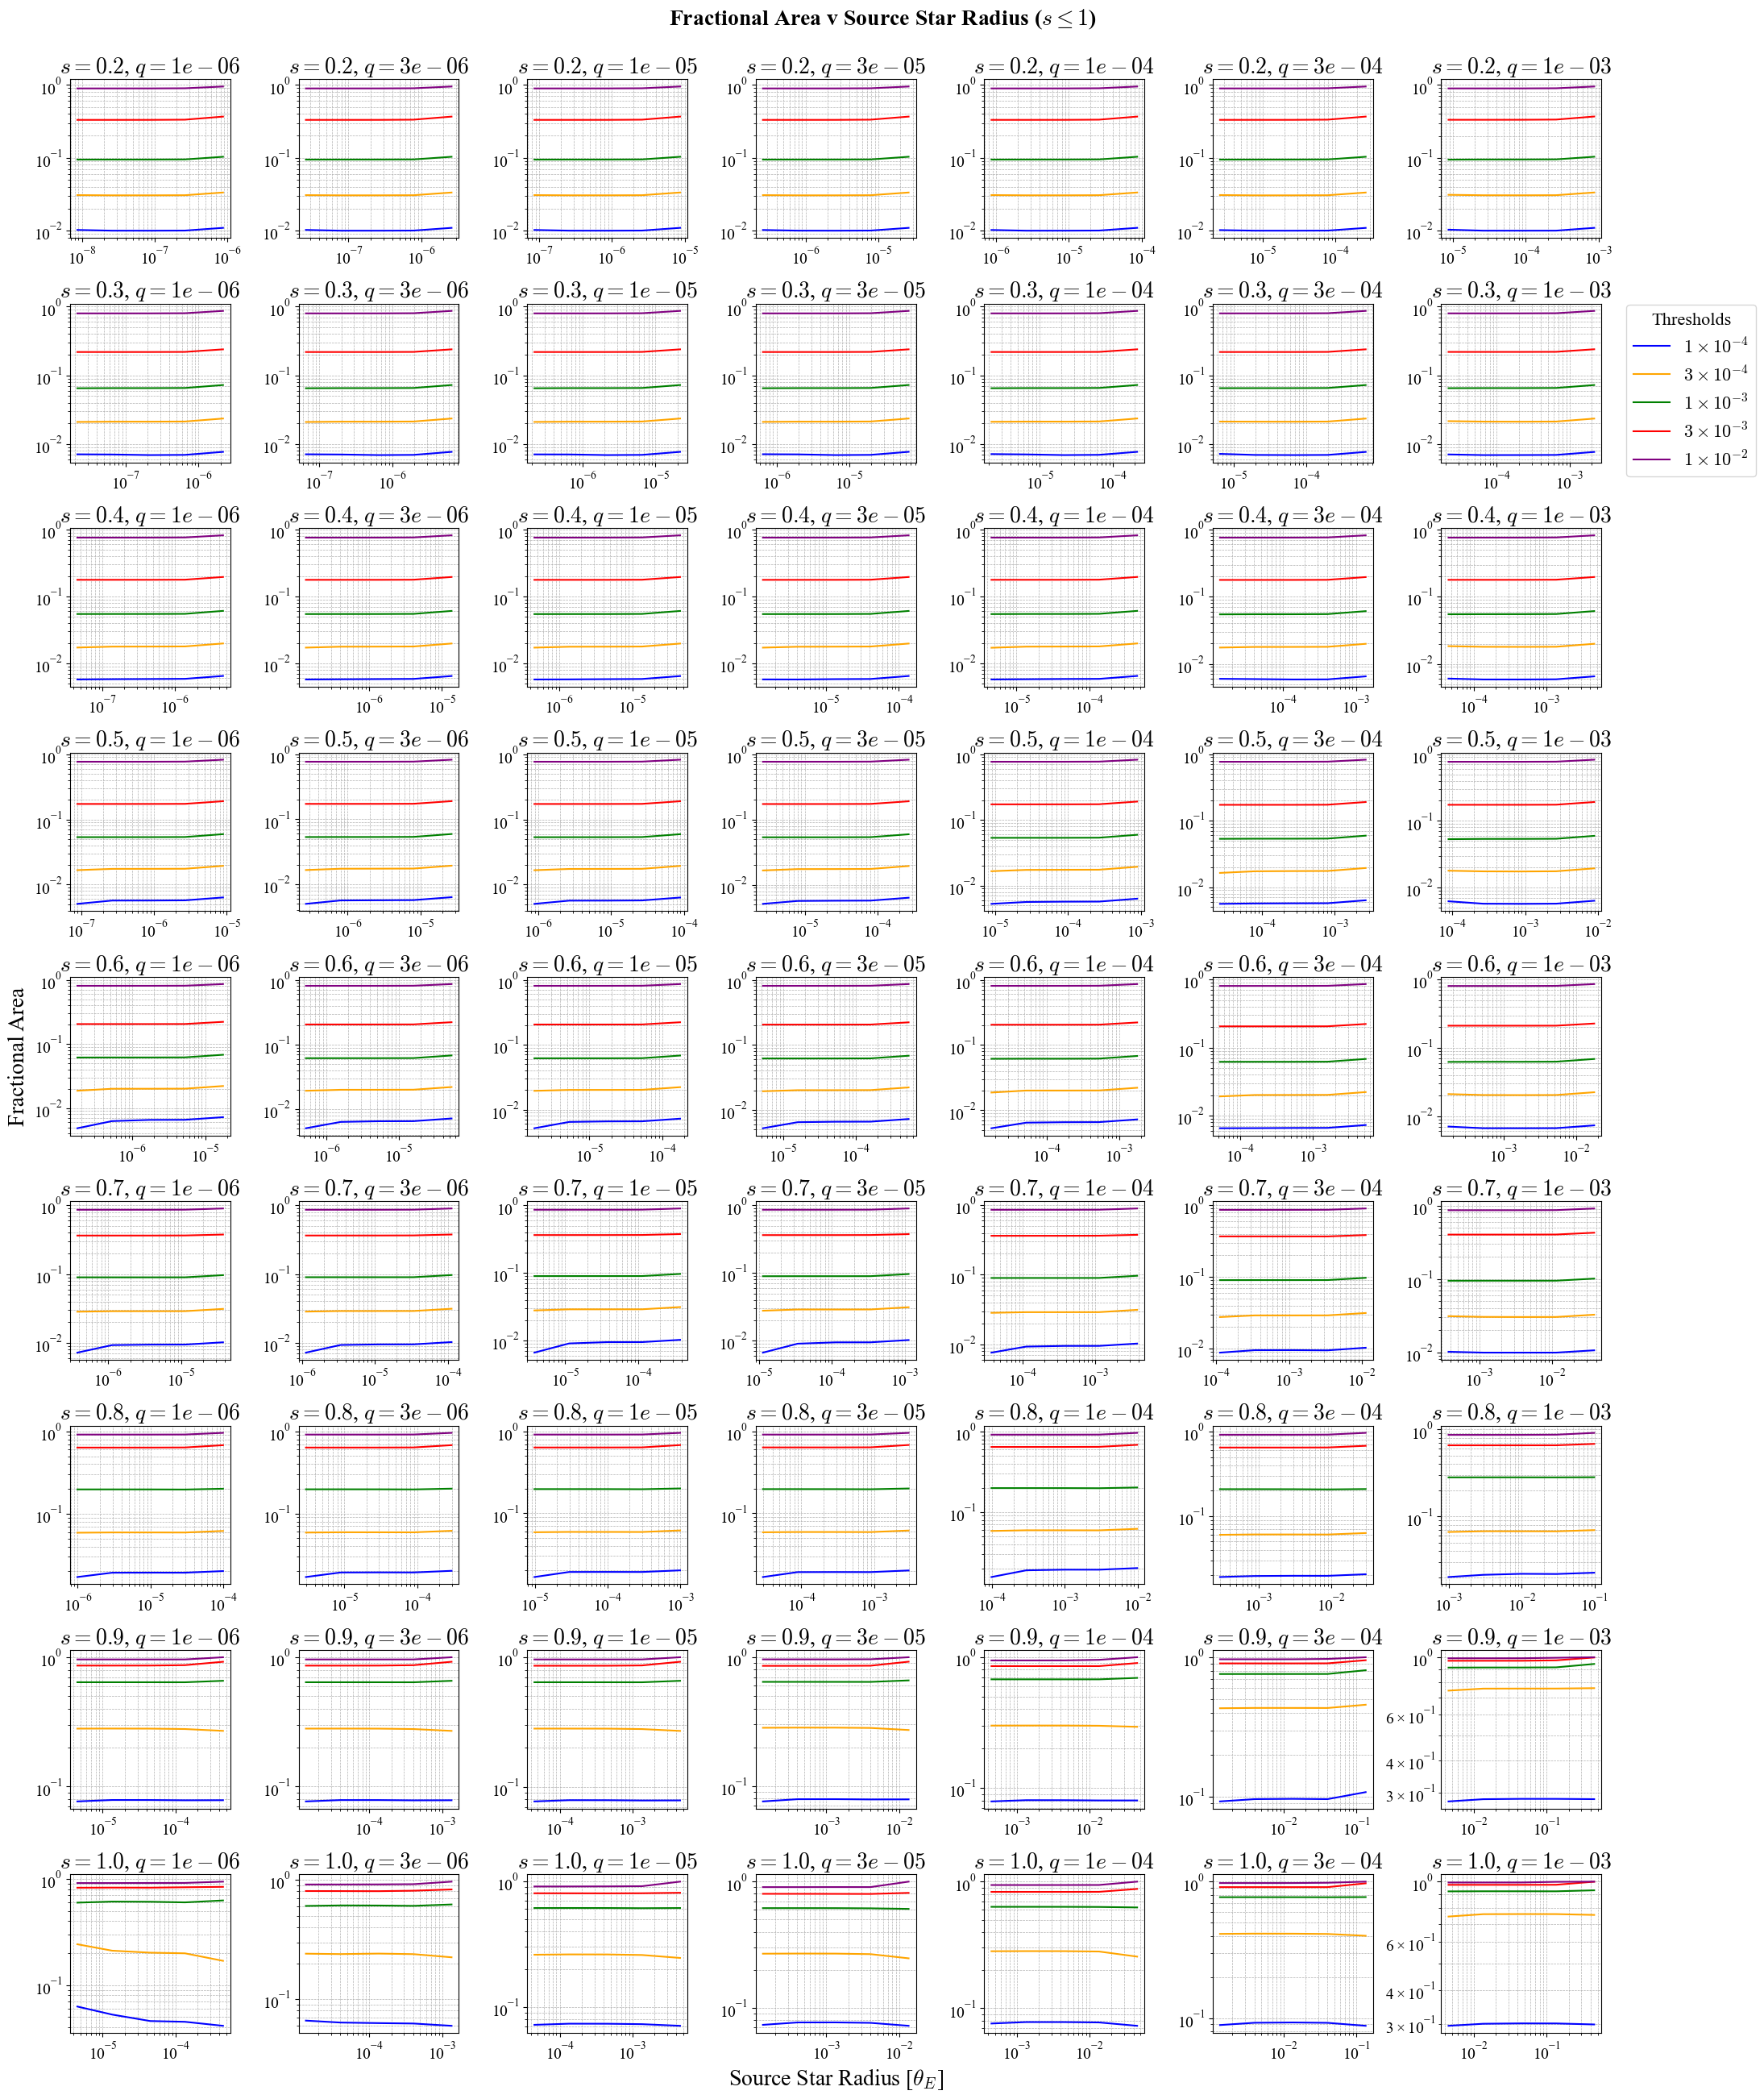

In [4]:
fig = plt.figure(figsize=(22, 26))
fig.set_tight_layout(True)
axes = fig.subplots(9, 7)

combined_df = pd.concat(df_list, ignore_index=True)

fig.suptitle('Fractional Area v Source Star Radius ($s \leq 1$)', y=1.0)

for i, s in enumerate(ss_str_unique_1[ss_unique_1 <= 1.0]):
    for j, q in enumerate(qs_unique_1):
        ax = axes[i, j]

        ax.set_title(f'$s={s}$, $q={q:.0e}$')

        df_subset = combined_df[(combined_df['s'] == s) & (combined_df['q'] == q)]
        df_subset = df_subset.sort_values(by='source_radius')

        ax.plot(df_subset['source_radius'], df_subset['1.1e-04'], label='$1 \\times 10^{-4}$', color='blue')
        ax.plot(df_subset['source_radius'], df_subset['3.4e-04'], label='$3 \\times 10^{-4}$', color='orange')
        ax.plot(df_subset['source_radius'], df_subset['1.0e-03'], label='$1 \\times 10^{-3}$', color='green')
        ax.plot(df_subset['source_radius'], df_subset['3.1e-03'], label='$3 \\times 10^{-3}$', color='red')
        ax.plot(df_subset['source_radius'], df_subset['1.1e-02'], label='$1 \\times 10^{-2}$', color='purple')

        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.grid(True, which='both', linestyle='--', linewidth=0.5)

axes[-1, 3].set_xlabel('Source Star Radius [$\\theta_E$]')
axes[4, 0].set_ylabel('Fractional Area')

axes[1, -1].legend(bbox_to_anchor=(1.1, 1.05), loc='upper left', title='Thresholds')

plt.show()

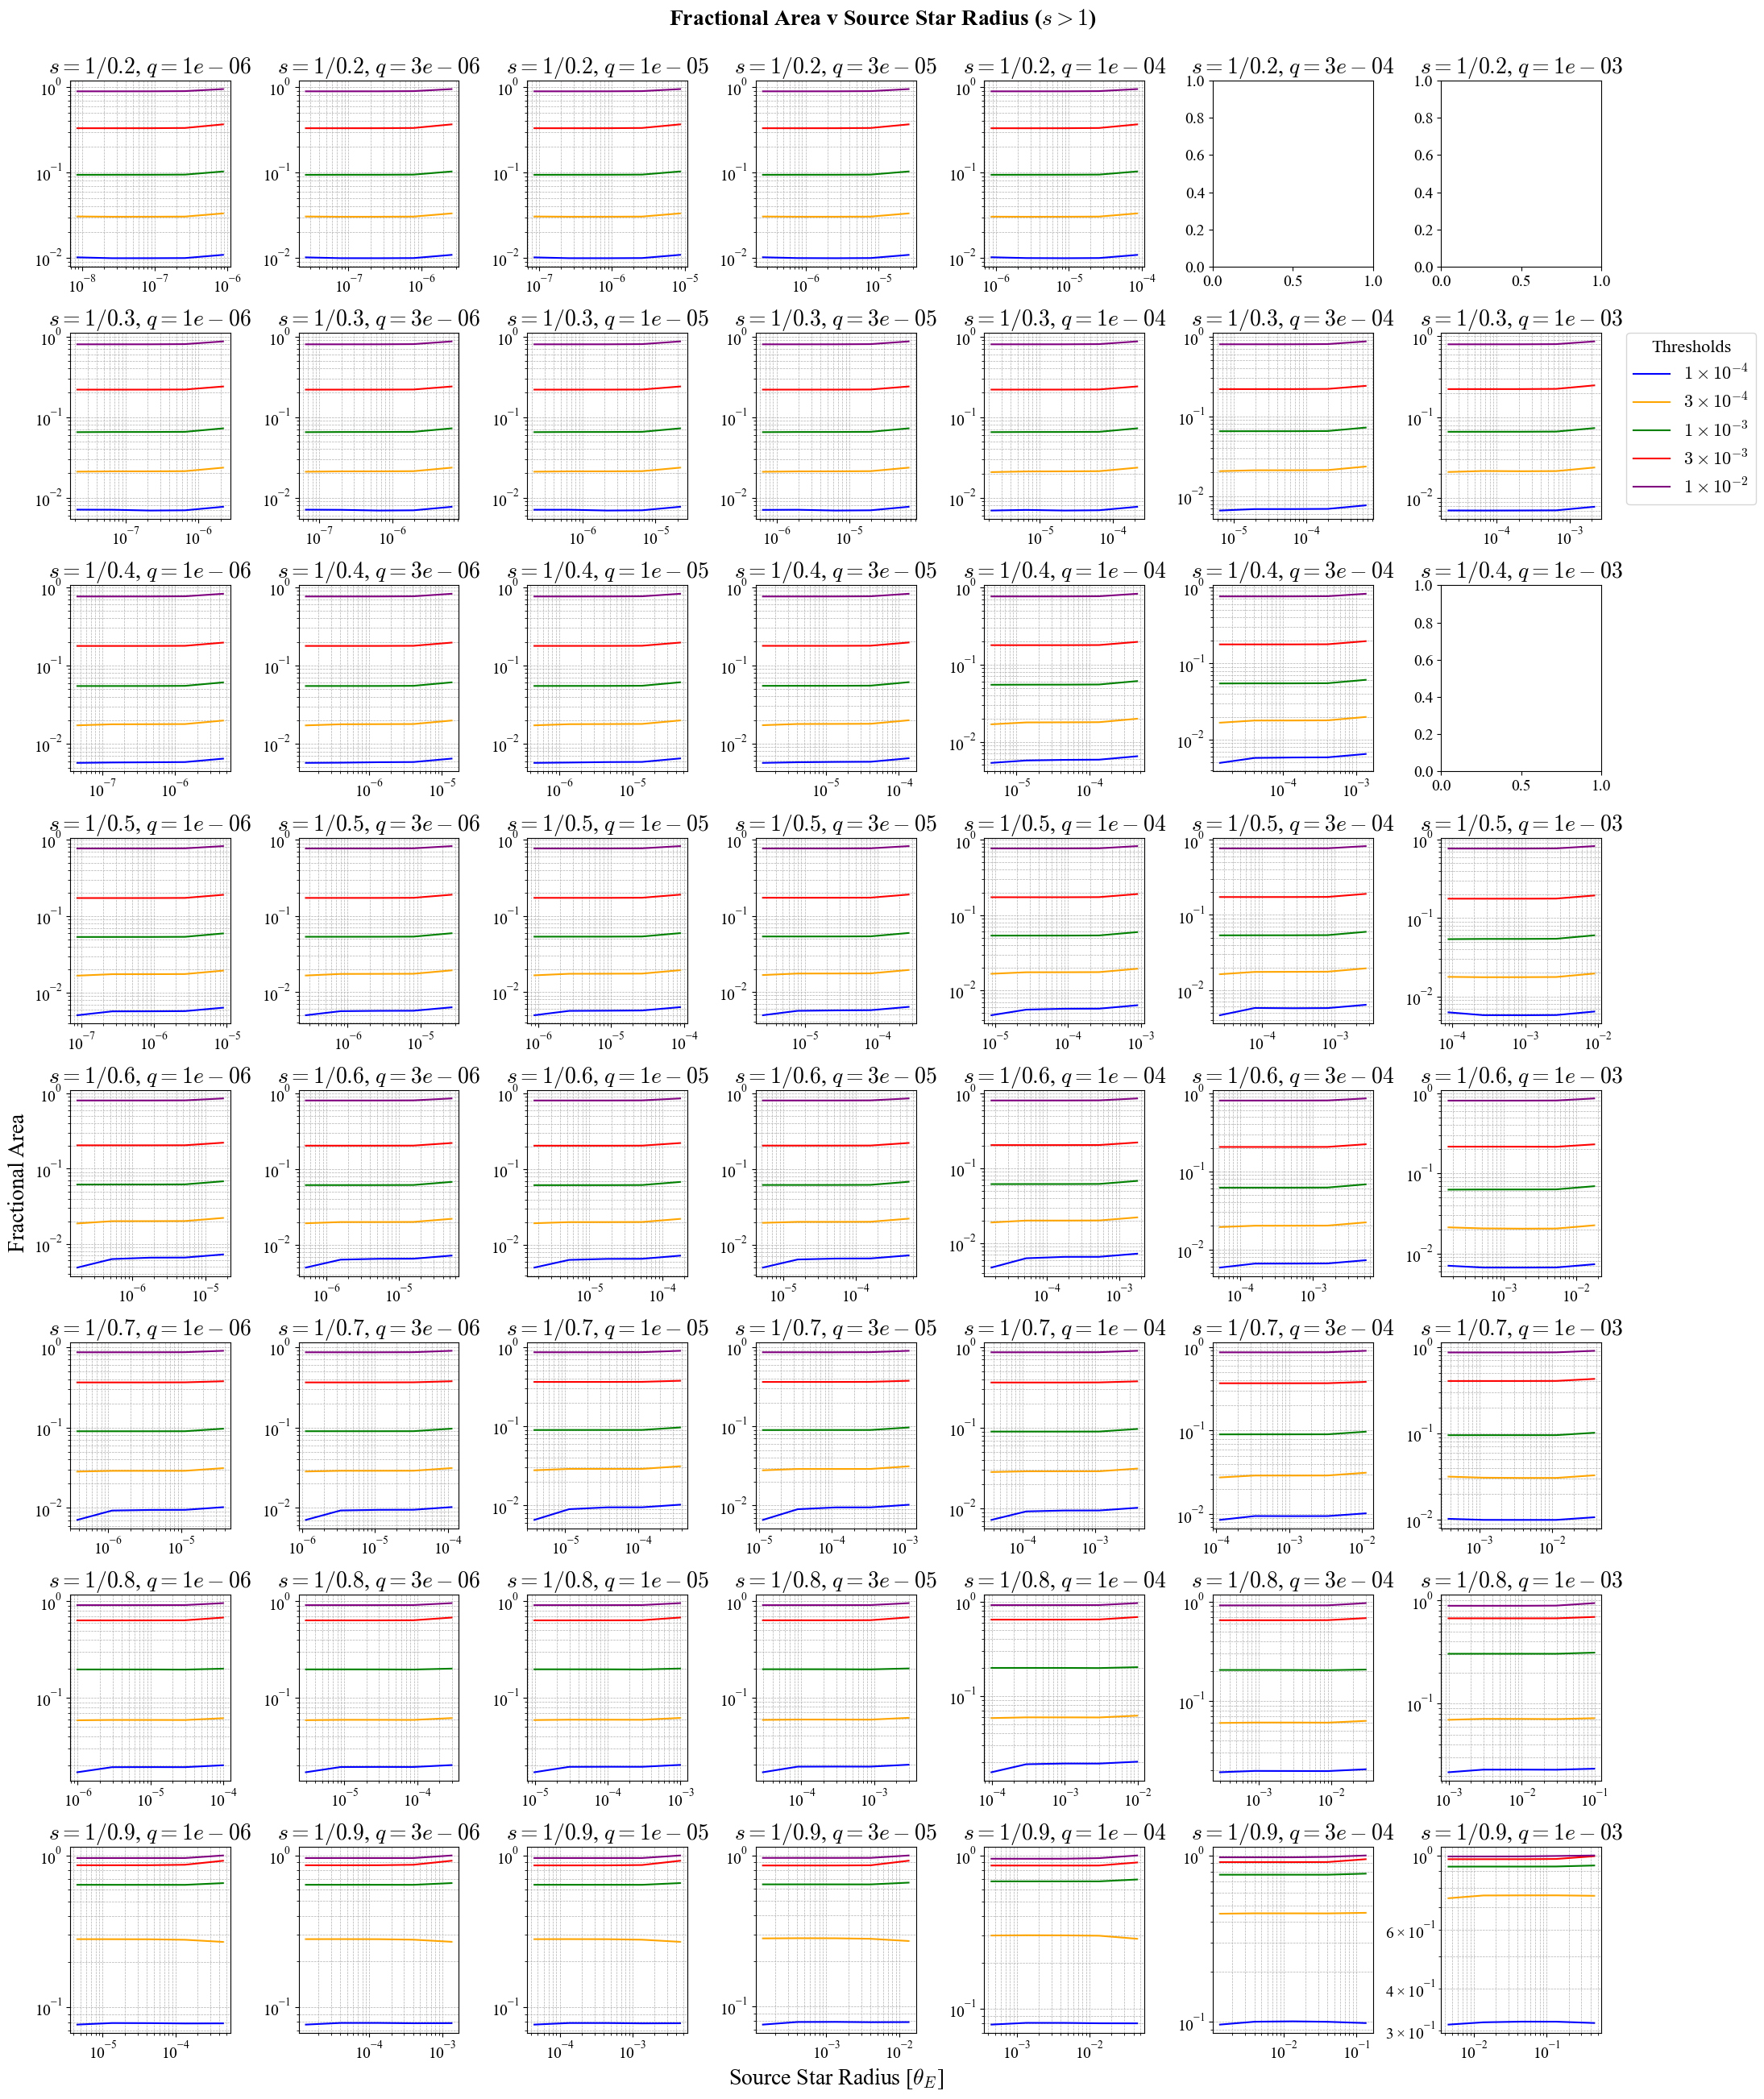

In [5]:
fig = plt.figure(figsize=(22, 26))
fig.set_tight_layout(True)
axes = fig.subplots(8, 7)

combined_df = pd.concat(df_list, ignore_index=True)

fig.suptitle('Fractional Area v Source Star Radius ($s > 1$)', y=1.0)

for i, s in enumerate(ss_str_unique_1[ss_unique_1 > 1.0]):
    for j, q in enumerate(qs_unique_1):
        ax = axes[i, j]

        ax.set_title(f'$s={s}$, $q={q:.0e}$')

        df_subset = combined_df[(combined_df['s'] == s) & (combined_df['q'] == q)]
        df_subset = df_subset.sort_values(by='source_radius')

        if df_subset.empty:
            continue

        ax.plot(df_subset['source_radius'], df_subset['1.1e-04'], label='$1 \\times 10^{-4}$', color='blue')
        ax.plot(df_subset['source_radius'], df_subset['3.4e-04'], label='$3 \\times 10^{-4}$', color='orange')
        ax.plot(df_subset['source_radius'], df_subset['1.0e-03'], label='$1 \\times 10^{-3}$', color='green')
        ax.plot(df_subset['source_radius'], df_subset['3.1e-03'], label='$3 \\times 10^{-3}$', color='red')
        ax.plot(df_subset['source_radius'], df_subset['1.1e-02'], label='$1 \\times 10^{-2}$', color='purple')

        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.grid(True, which='both', linestyle='--', linewidth=0.5)

axes[-1, 3].set_xlabel('Source Star Radius [$\\theta_E$]')
axes[4, 0].set_ylabel('Fractional Area')

axes[1, -1].legend(bbox_to_anchor=(1.1, 1.05), loc='upper left', title='Thresholds')

plt.show()

# Second, plotting fractional area as a function of separation for different thresholds

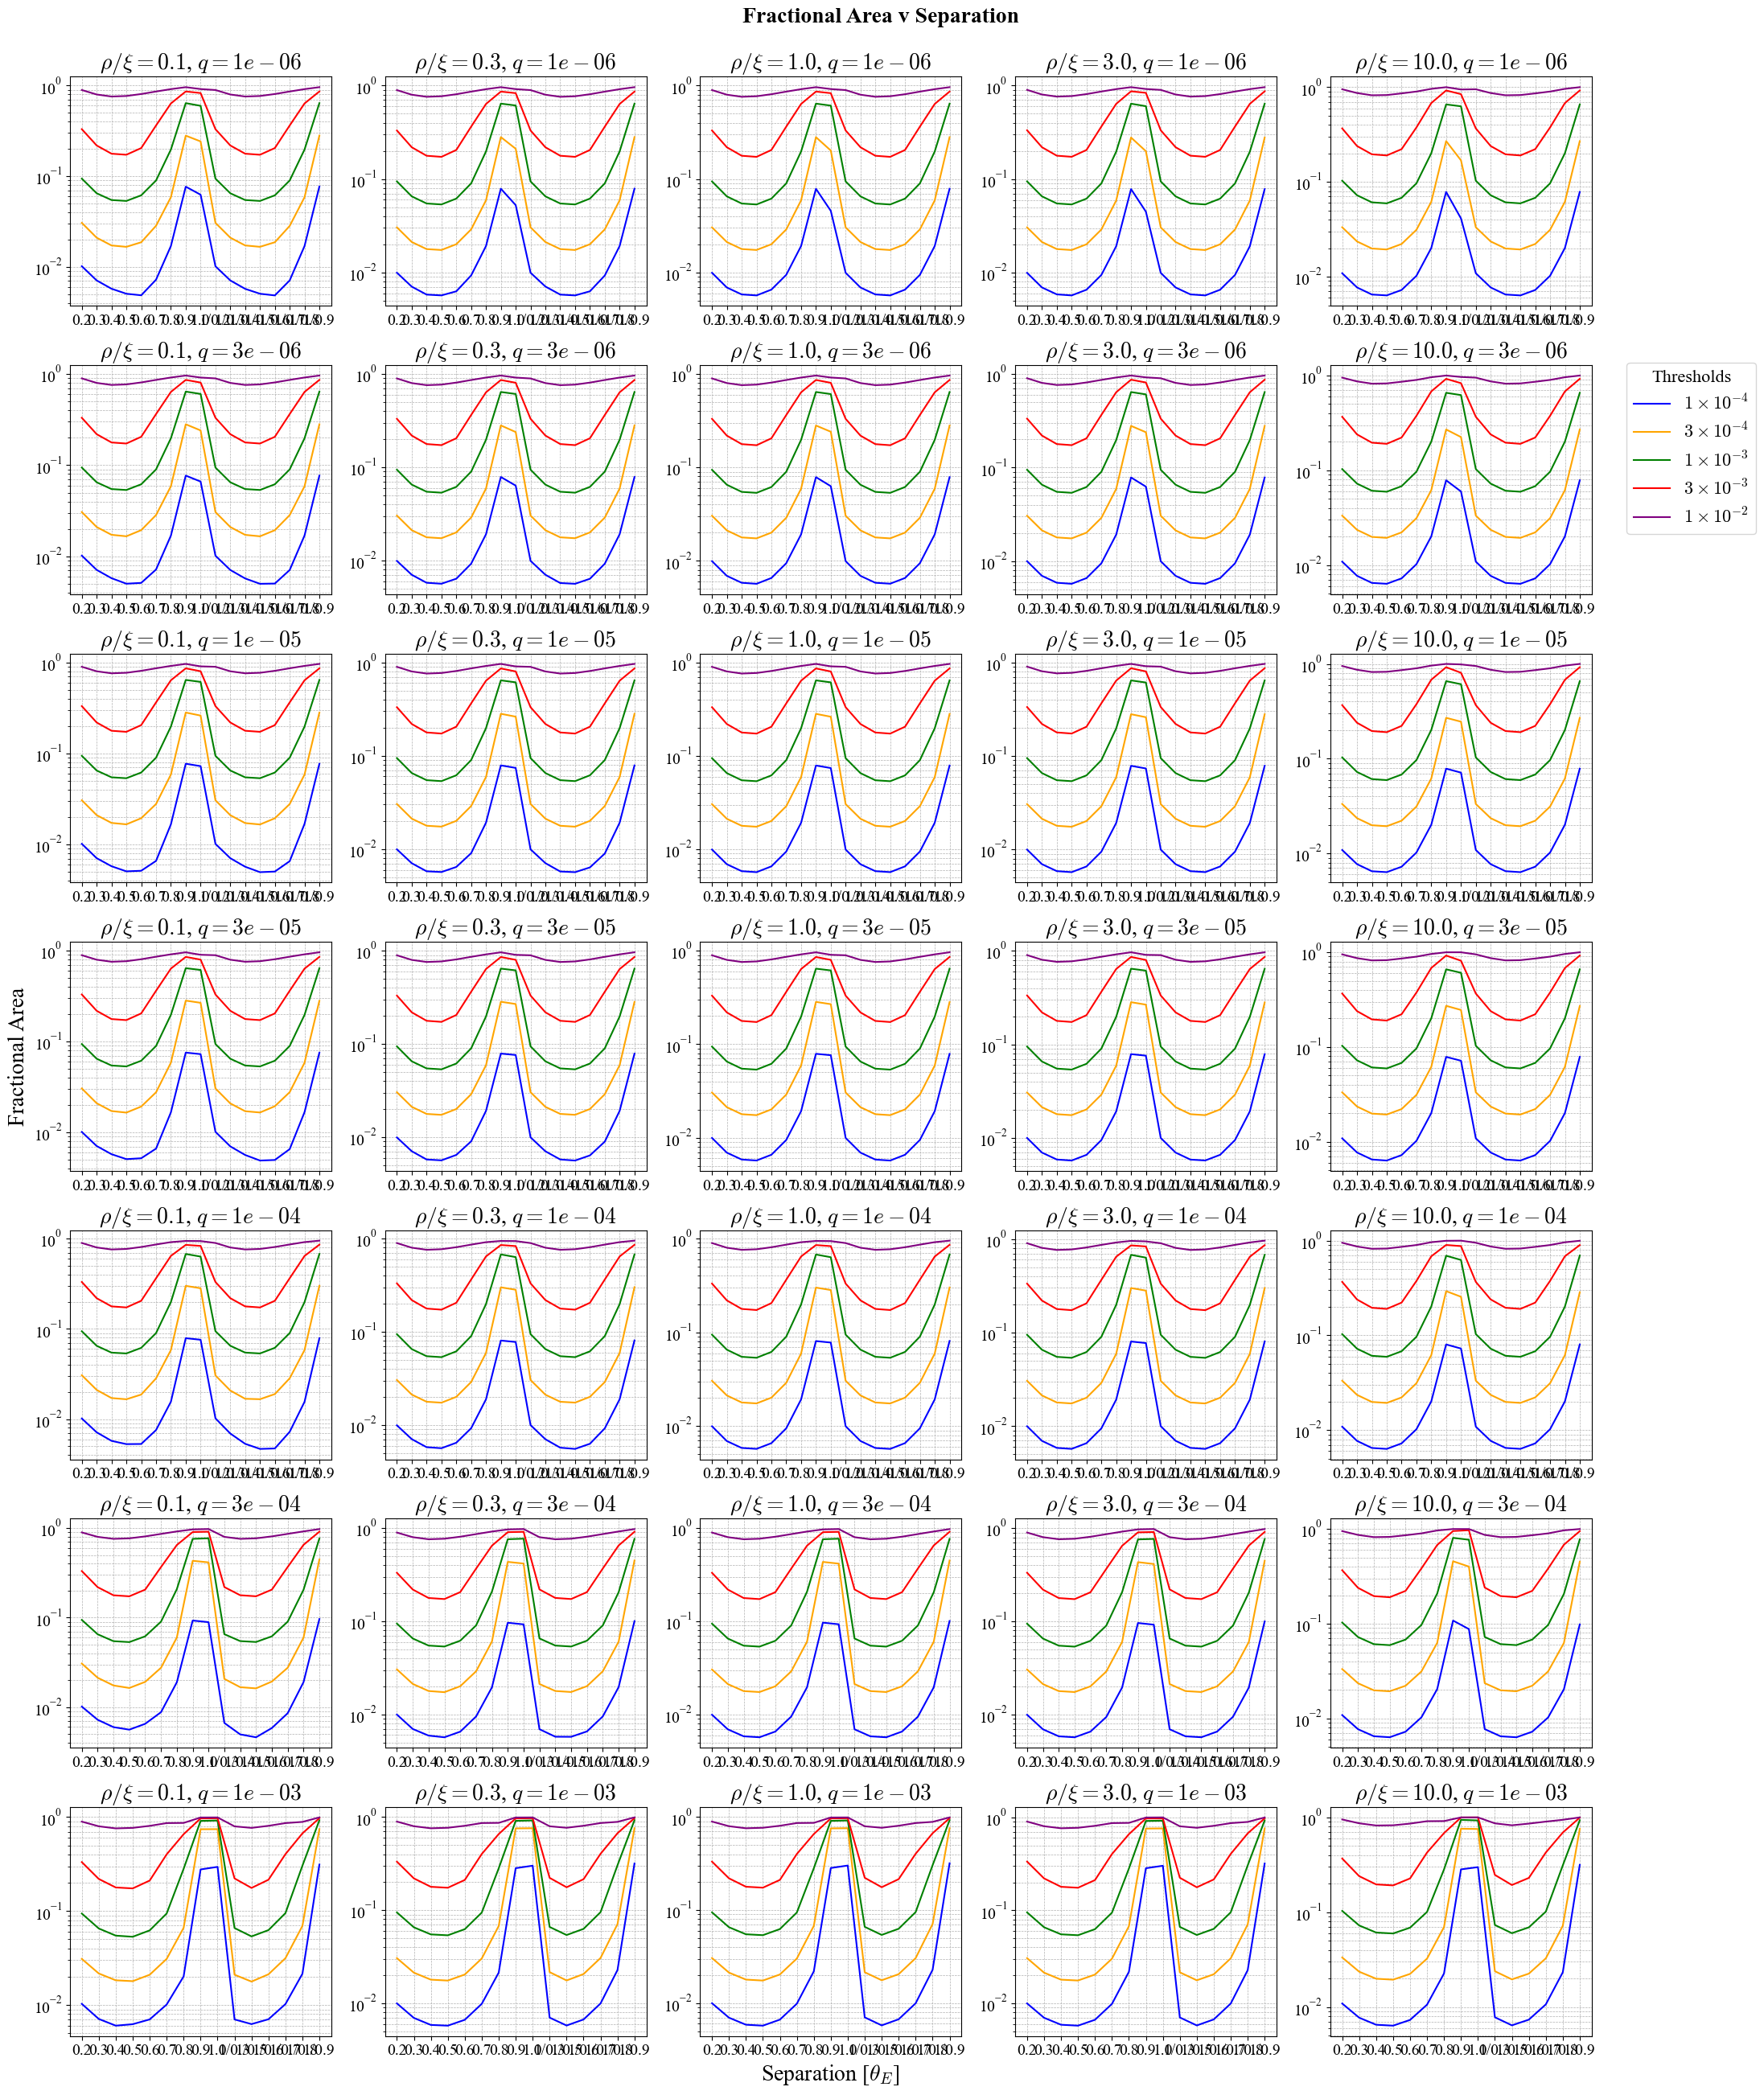

In [17]:
fig = plt.figure(figsize=(22, 26))
fig.set_tight_layout(True)
axes = fig.subplots(7, 5)

combined_df = pd.concat(df_list, ignore_index=True)

fig.suptitle('Fractional Area v Separation', y=1.0)

for i, q in enumerate(qs_unique_1):
    for j, multiplier in enumerate(multipliers):
        ax = axes[i, j]

        ax.set_title(f'$\\rho/\\xi={multiplier}$, $q={q:.0e}$')

        df_subset = df_list[j][(df_list[j]['q'] == q)]
        df_subset = df_subset.sort_values(by='s')

        ax.plot(df_subset['s'], df_subset['1.1e-04'], label='$1 \\times 10^{-4}$', color='blue')
        ax.plot(df_subset['s'], df_subset['3.4e-04'], label='$3 \\times 10^{-4}$', color='orange')
        ax.plot(df_subset['s'], df_subset['1.0e-03'], label='$1 \\times 10^{-3}$', color='green')
        ax.plot(df_subset['s'], df_subset['3.1e-03'], label='$3 \\times 10^{-3}$', color='red')
        ax.plot(df_subset['s'], df_subset['1.1e-02'], label='$1 \\times 10^{-2}$', color='purple')
        # ax.set_xscale('log')
        ax.set_yscale('log')
        ax.grid(True, which='both', linestyle='--', linewidth=0.5)

axes[-1, 2].set_xlabel('Separation [$\\theta_E$]')
axes[3, 0].set_ylabel('Fractional Area')

axes[1, -1].legend(bbox_to_anchor=(1.1, 1.05), loc='upper left', title='Thresholds')

plt.show()

## Third, plotting fractional area as a function of q for different thesholds

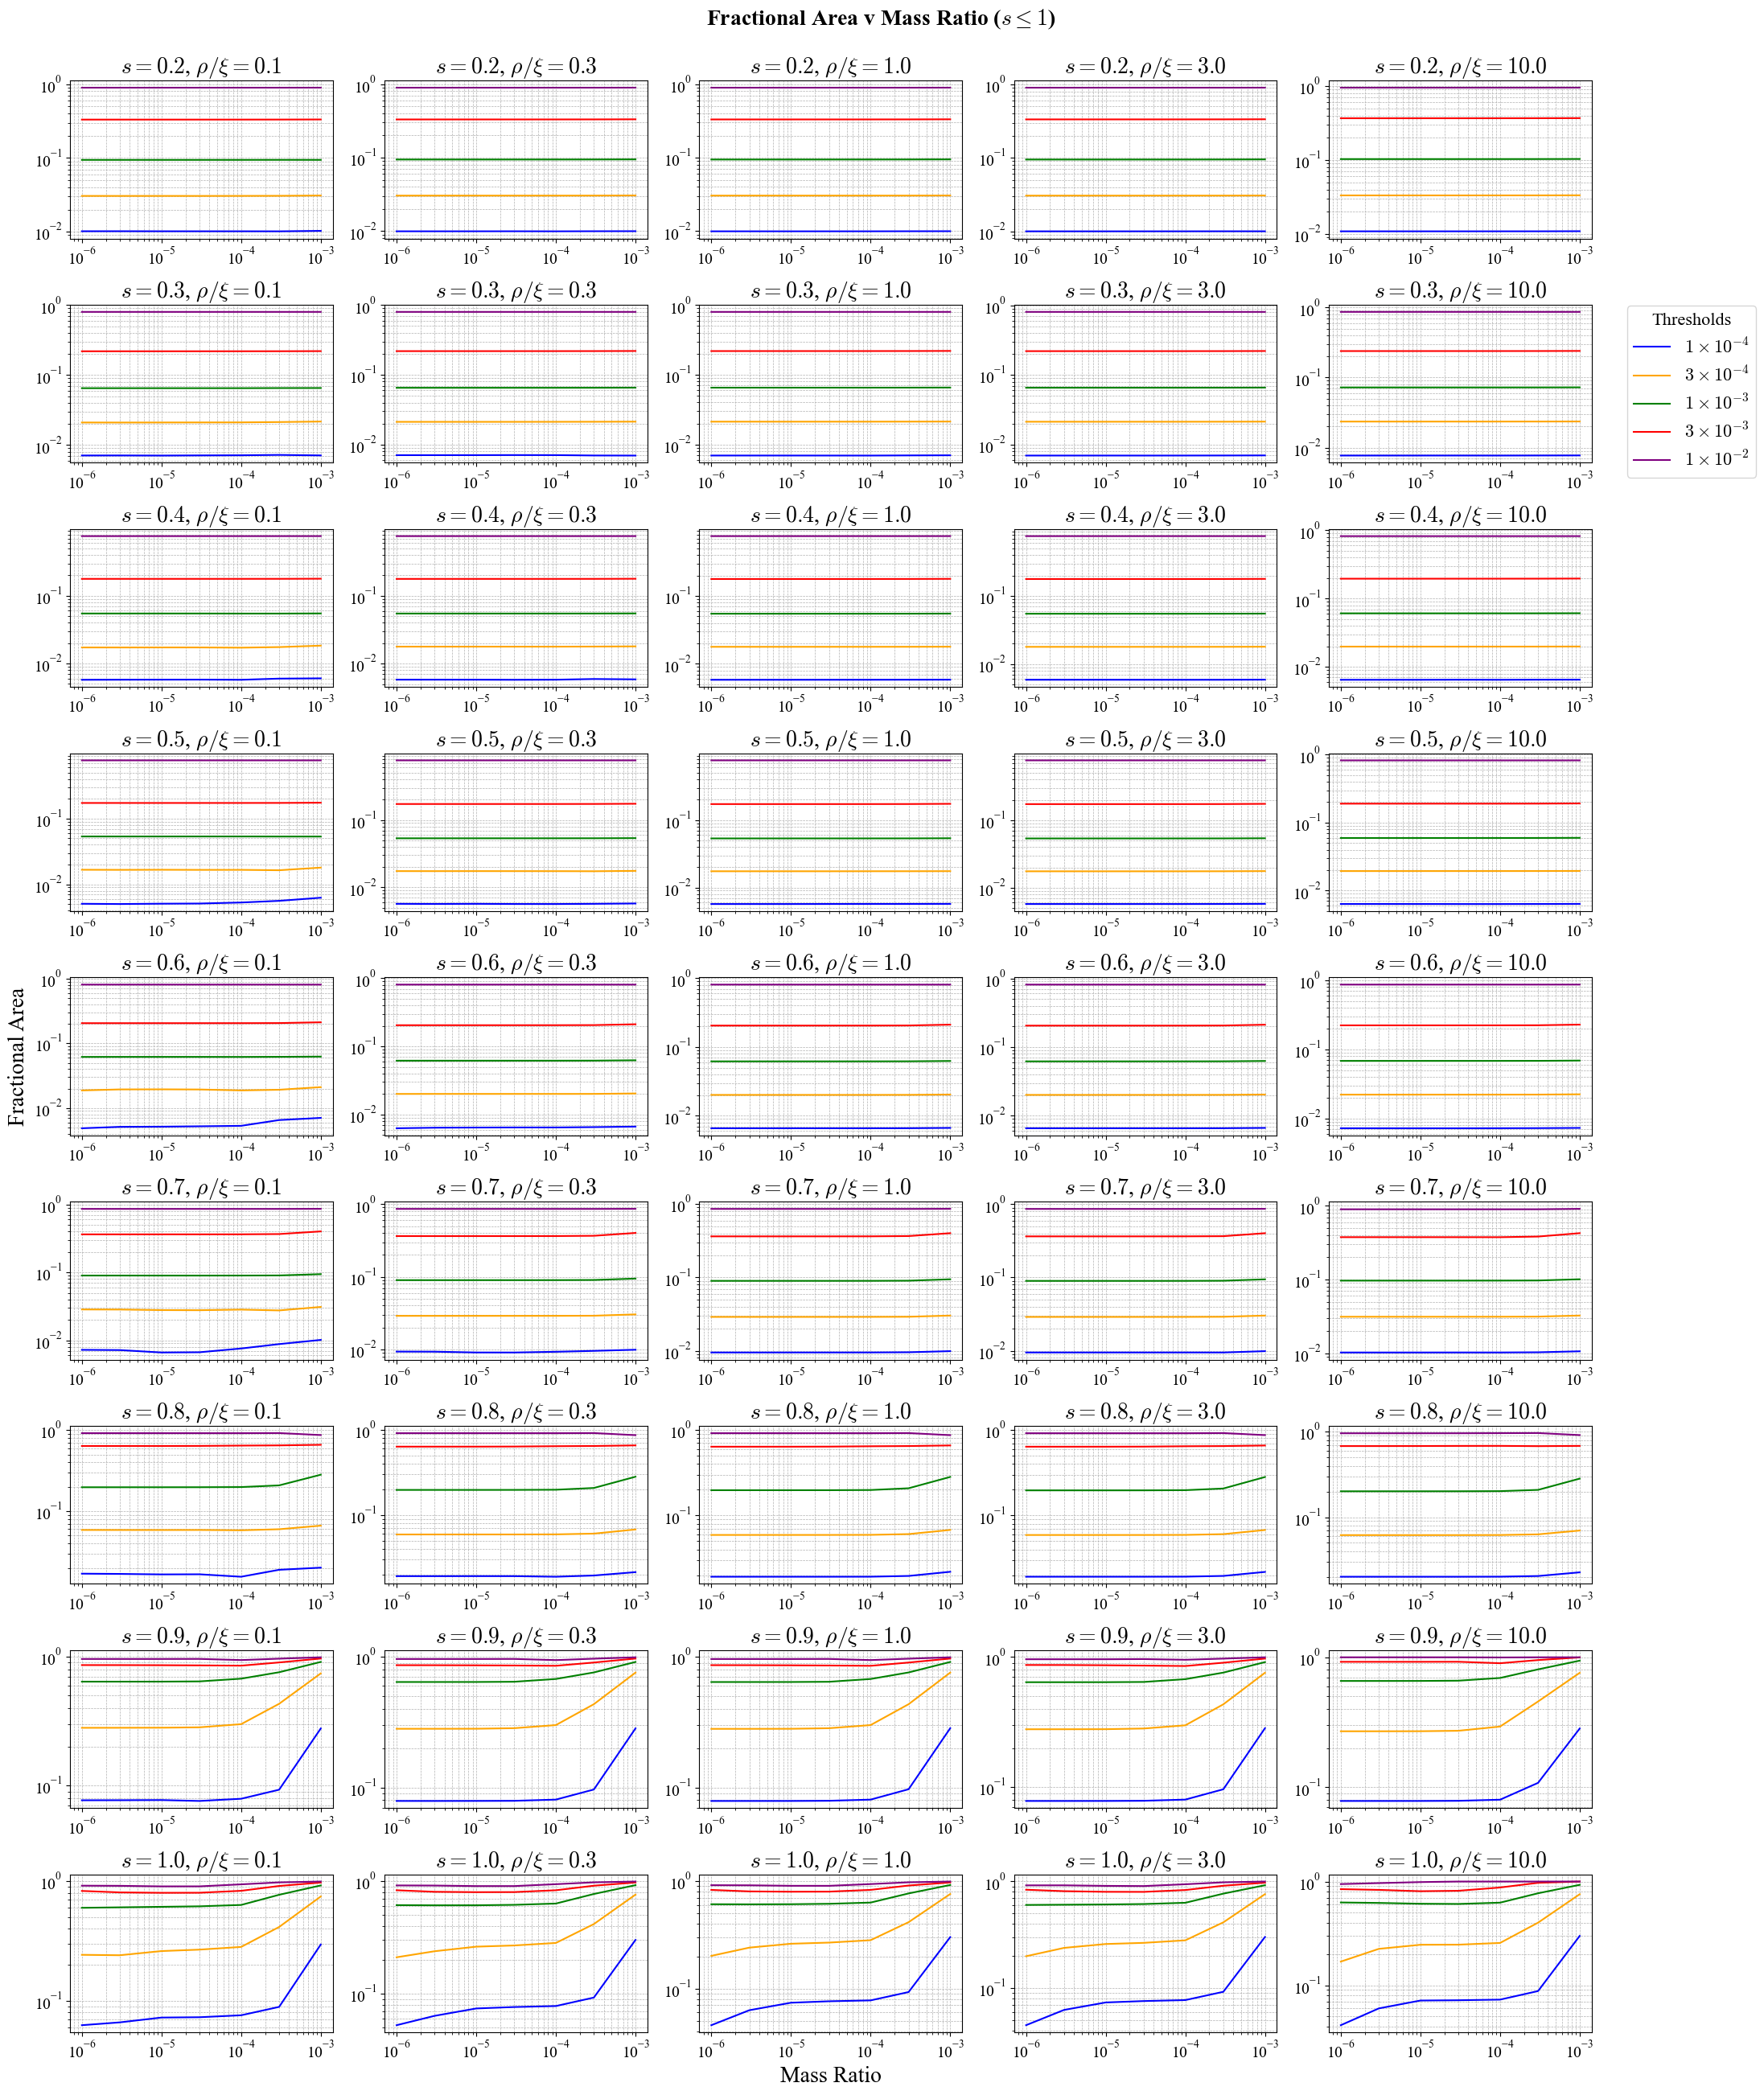

In [19]:
fig = plt.figure(figsize=(22, 26))
fig.set_tight_layout(True)
axes = fig.subplots(9, 5)

combined_df = pd.concat(df_list, ignore_index=True)

fig.suptitle('Fractional Area v Mass Ratio ($s \leq 1$)', y=1.0)

for i, s in enumerate(ss_str_unique_1[ss_unique_1 <= 1.0]):
    for j, multiplier in enumerate(multipliers):
        ax = axes[i, j]

        ax.set_title(f'$s={s}$, $\\rho/\\xi={multiplier}$')

        df_subset = df_list[j][(df_list[j]['s'] == s)]
        df_subset = df_subset.sort_values(by='q')

        ax.plot(df_subset['q'], df_subset['1.1e-04'], label='$1 \\times 10^{-4}$', color='blue')
        ax.plot(df_subset['q'], df_subset['3.4e-04'], label='$3 \\times 10^{-4}$', color='orange')
        ax.plot(df_subset['q'], df_subset['1.0e-03'], label='$1 \\times 10^{-3}$', color='green')
        ax.plot(df_subset['q'], df_subset['3.1e-03'], label='$3 \\times 10^{-3}$', color='red')
        ax.plot(df_subset['q'], df_subset['1.1e-02'], label='$1 \\times 10^{-2}$', color='purple')

        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.grid(True, which='both', linestyle='--', linewidth=0.5)

axes[-1, 2].set_xlabel('Mass Ratio')
axes[4, 0].set_ylabel('Fractional Area')

axes[1, -1].legend(bbox_to_anchor=(1.1, 1.05), loc='upper left', title='Thresholds')

plt.show()

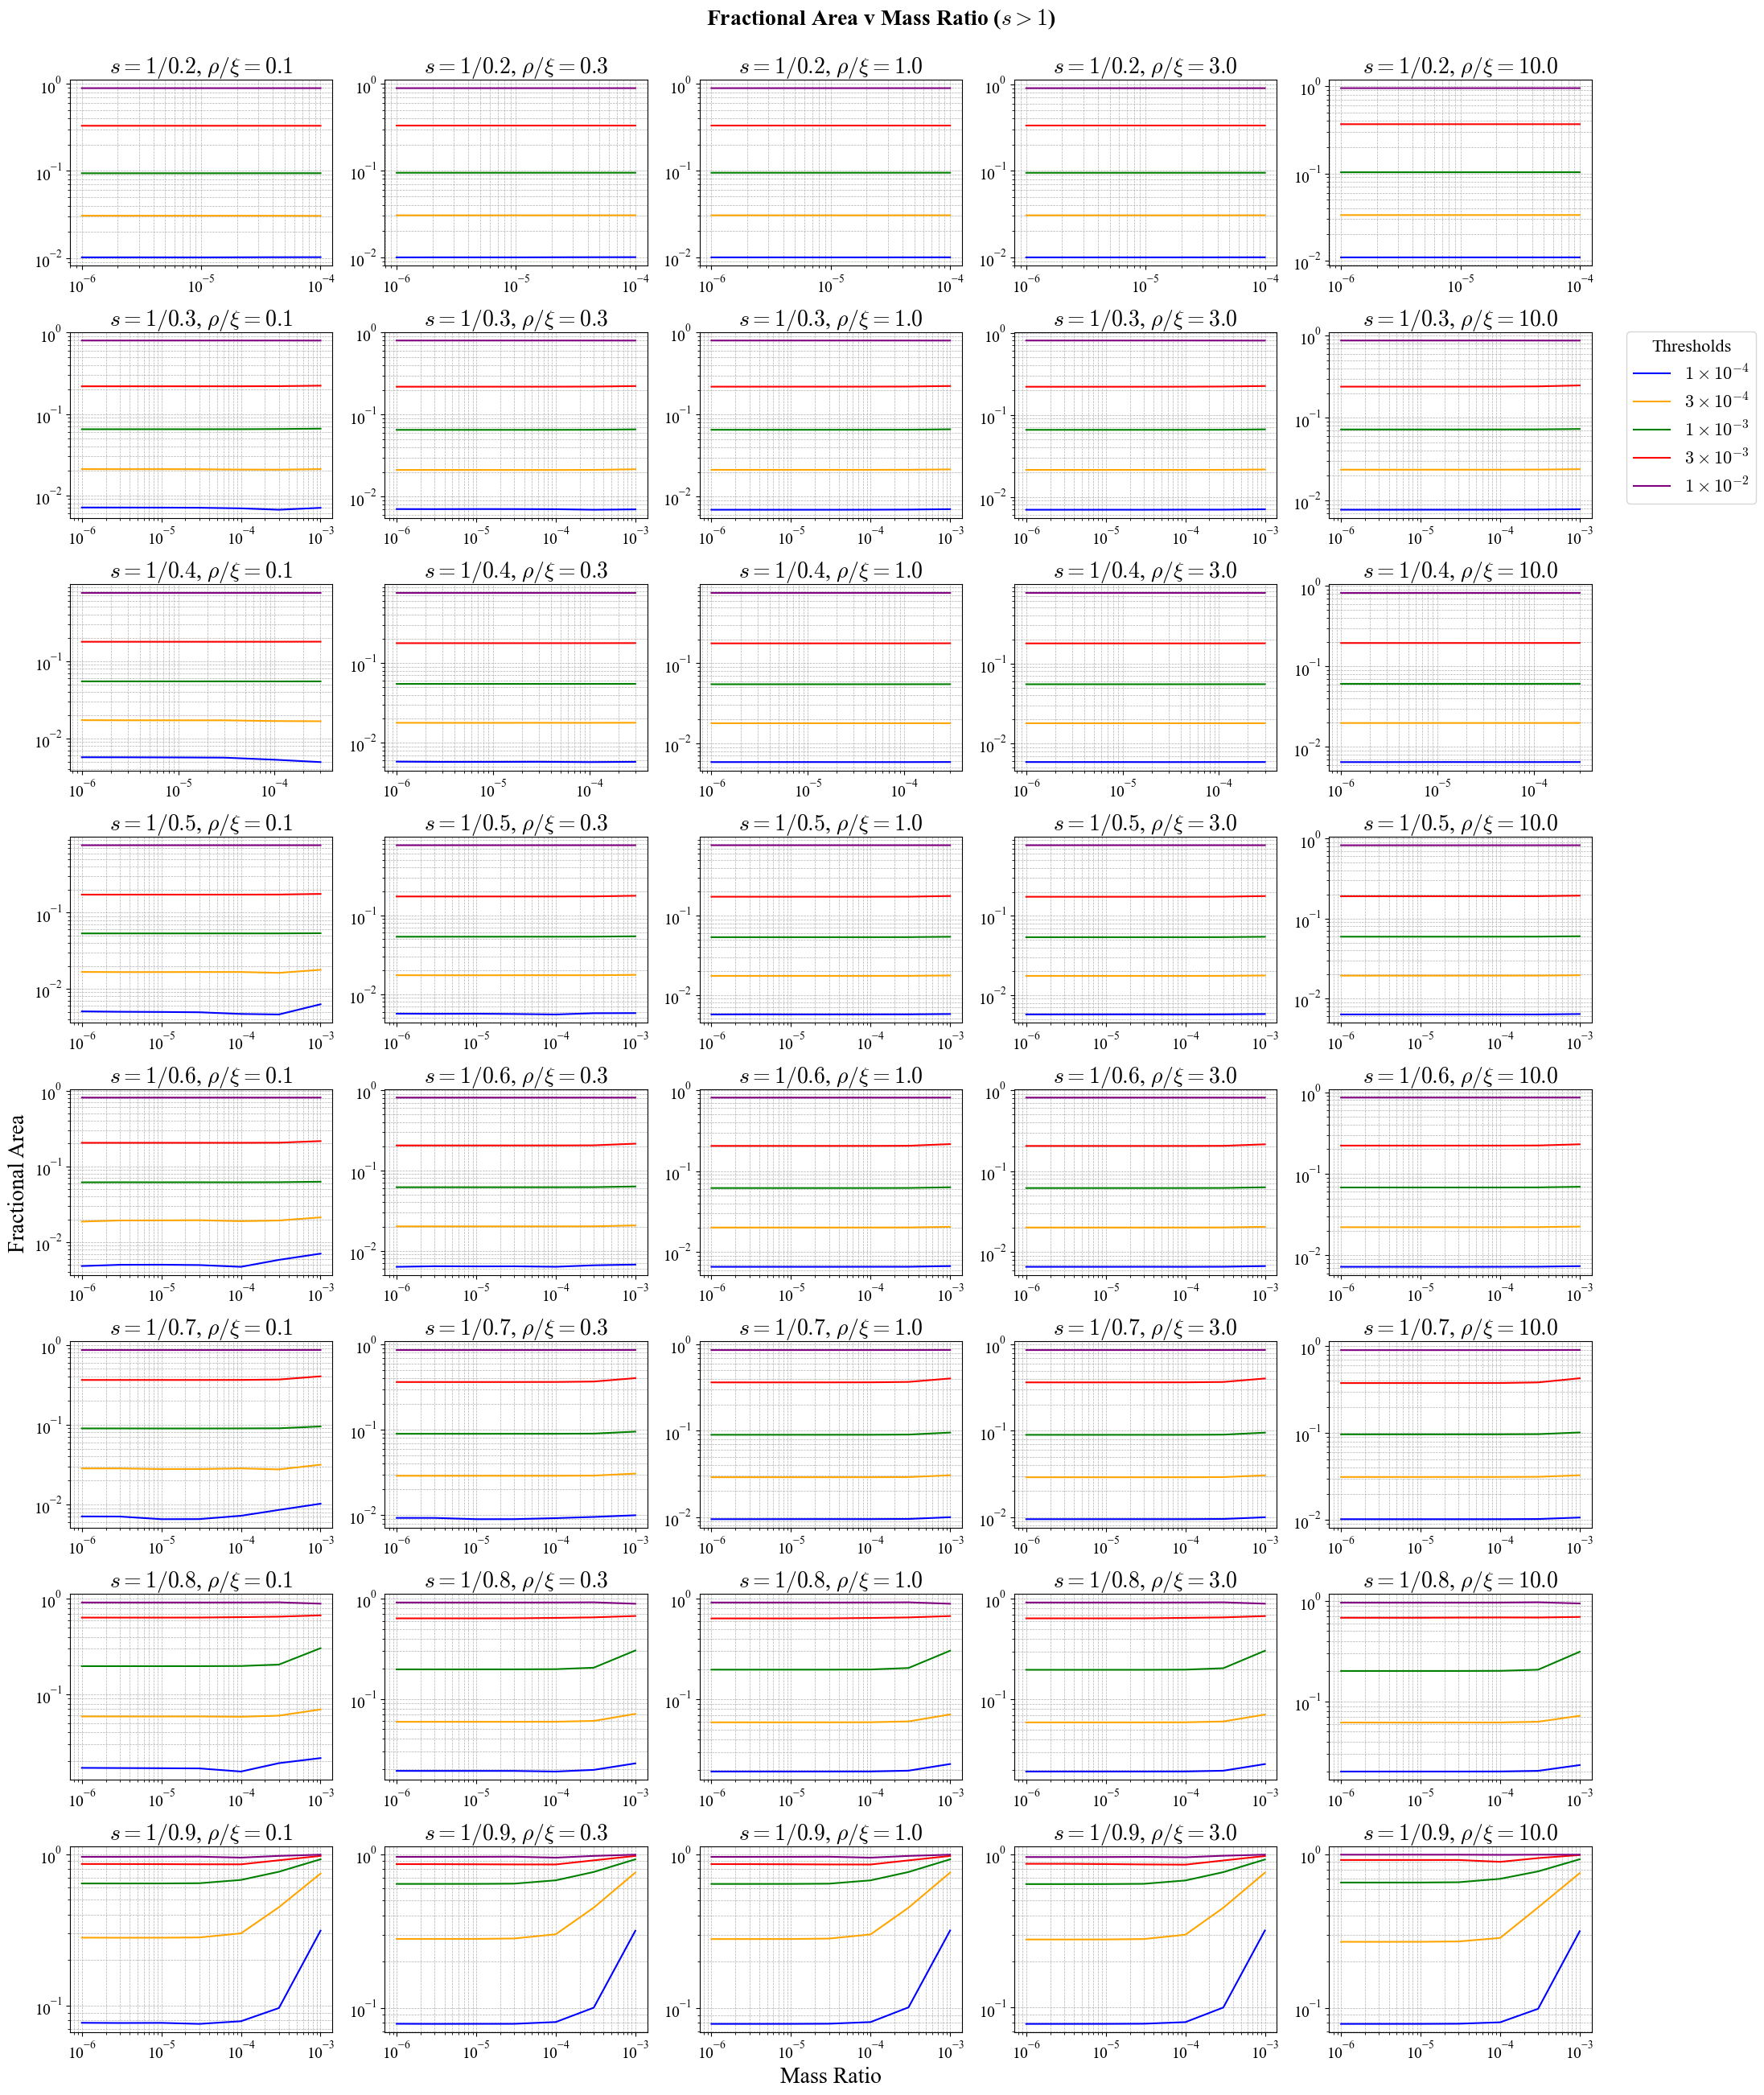

In [20]:
fig = plt.figure(figsize=(22, 26))
fig.set_tight_layout(True)
axes = fig.subplots(8, 5)

combined_df = pd.concat(df_list, ignore_index=True)

fig.suptitle('Fractional Area v Mass Ratio ($s > 1$)', y=1.0)

for i, s in enumerate(ss_str_unique_1[ss_unique_1 > 1.0]):
    for j, multiplier in enumerate(multipliers):
        ax = axes[i, j]

        ax.set_title(f'$s={s}$, $\\rho/\\xi={multiplier}$')

        df_subset = df_list[j][(df_list[j]['s'] == s)]
        df_subset = df_subset.sort_values(by='q')

        ax.plot(df_subset['q'], df_subset['1.1e-04'], label='$1 \\times 10^{-4}$', color='blue')
        ax.plot(df_subset['q'], df_subset['3.4e-04'], label='$3 \\times 10^{-4}$', color='orange')
        ax.plot(df_subset['q'], df_subset['1.0e-03'], label='$1 \\times 10^{-3}$', color='green')
        ax.plot(df_subset['q'], df_subset['3.1e-03'], label='$3 \\times 10^{-3}$', color='red')
        ax.plot(df_subset['q'], df_subset['1.1e-02'], label='$1 \\times 10^{-2}$', color='purple')

        ax.set_xscale('log')
        ax.set_yscale('log')
        ax.grid(True, which='both', linestyle='--', linewidth=0.5)

axes[-1, 2].set_xlabel('Mass Ratio')
axes[4, 0].set_ylabel('Fractional Area')

axes[1, -1].legend(bbox_to_anchor=(1.1, 1.05), loc='upper left', title='Thresholds')

plt.show()

## Fourth, plotting q and s with fractional area as color scale for different thresholds

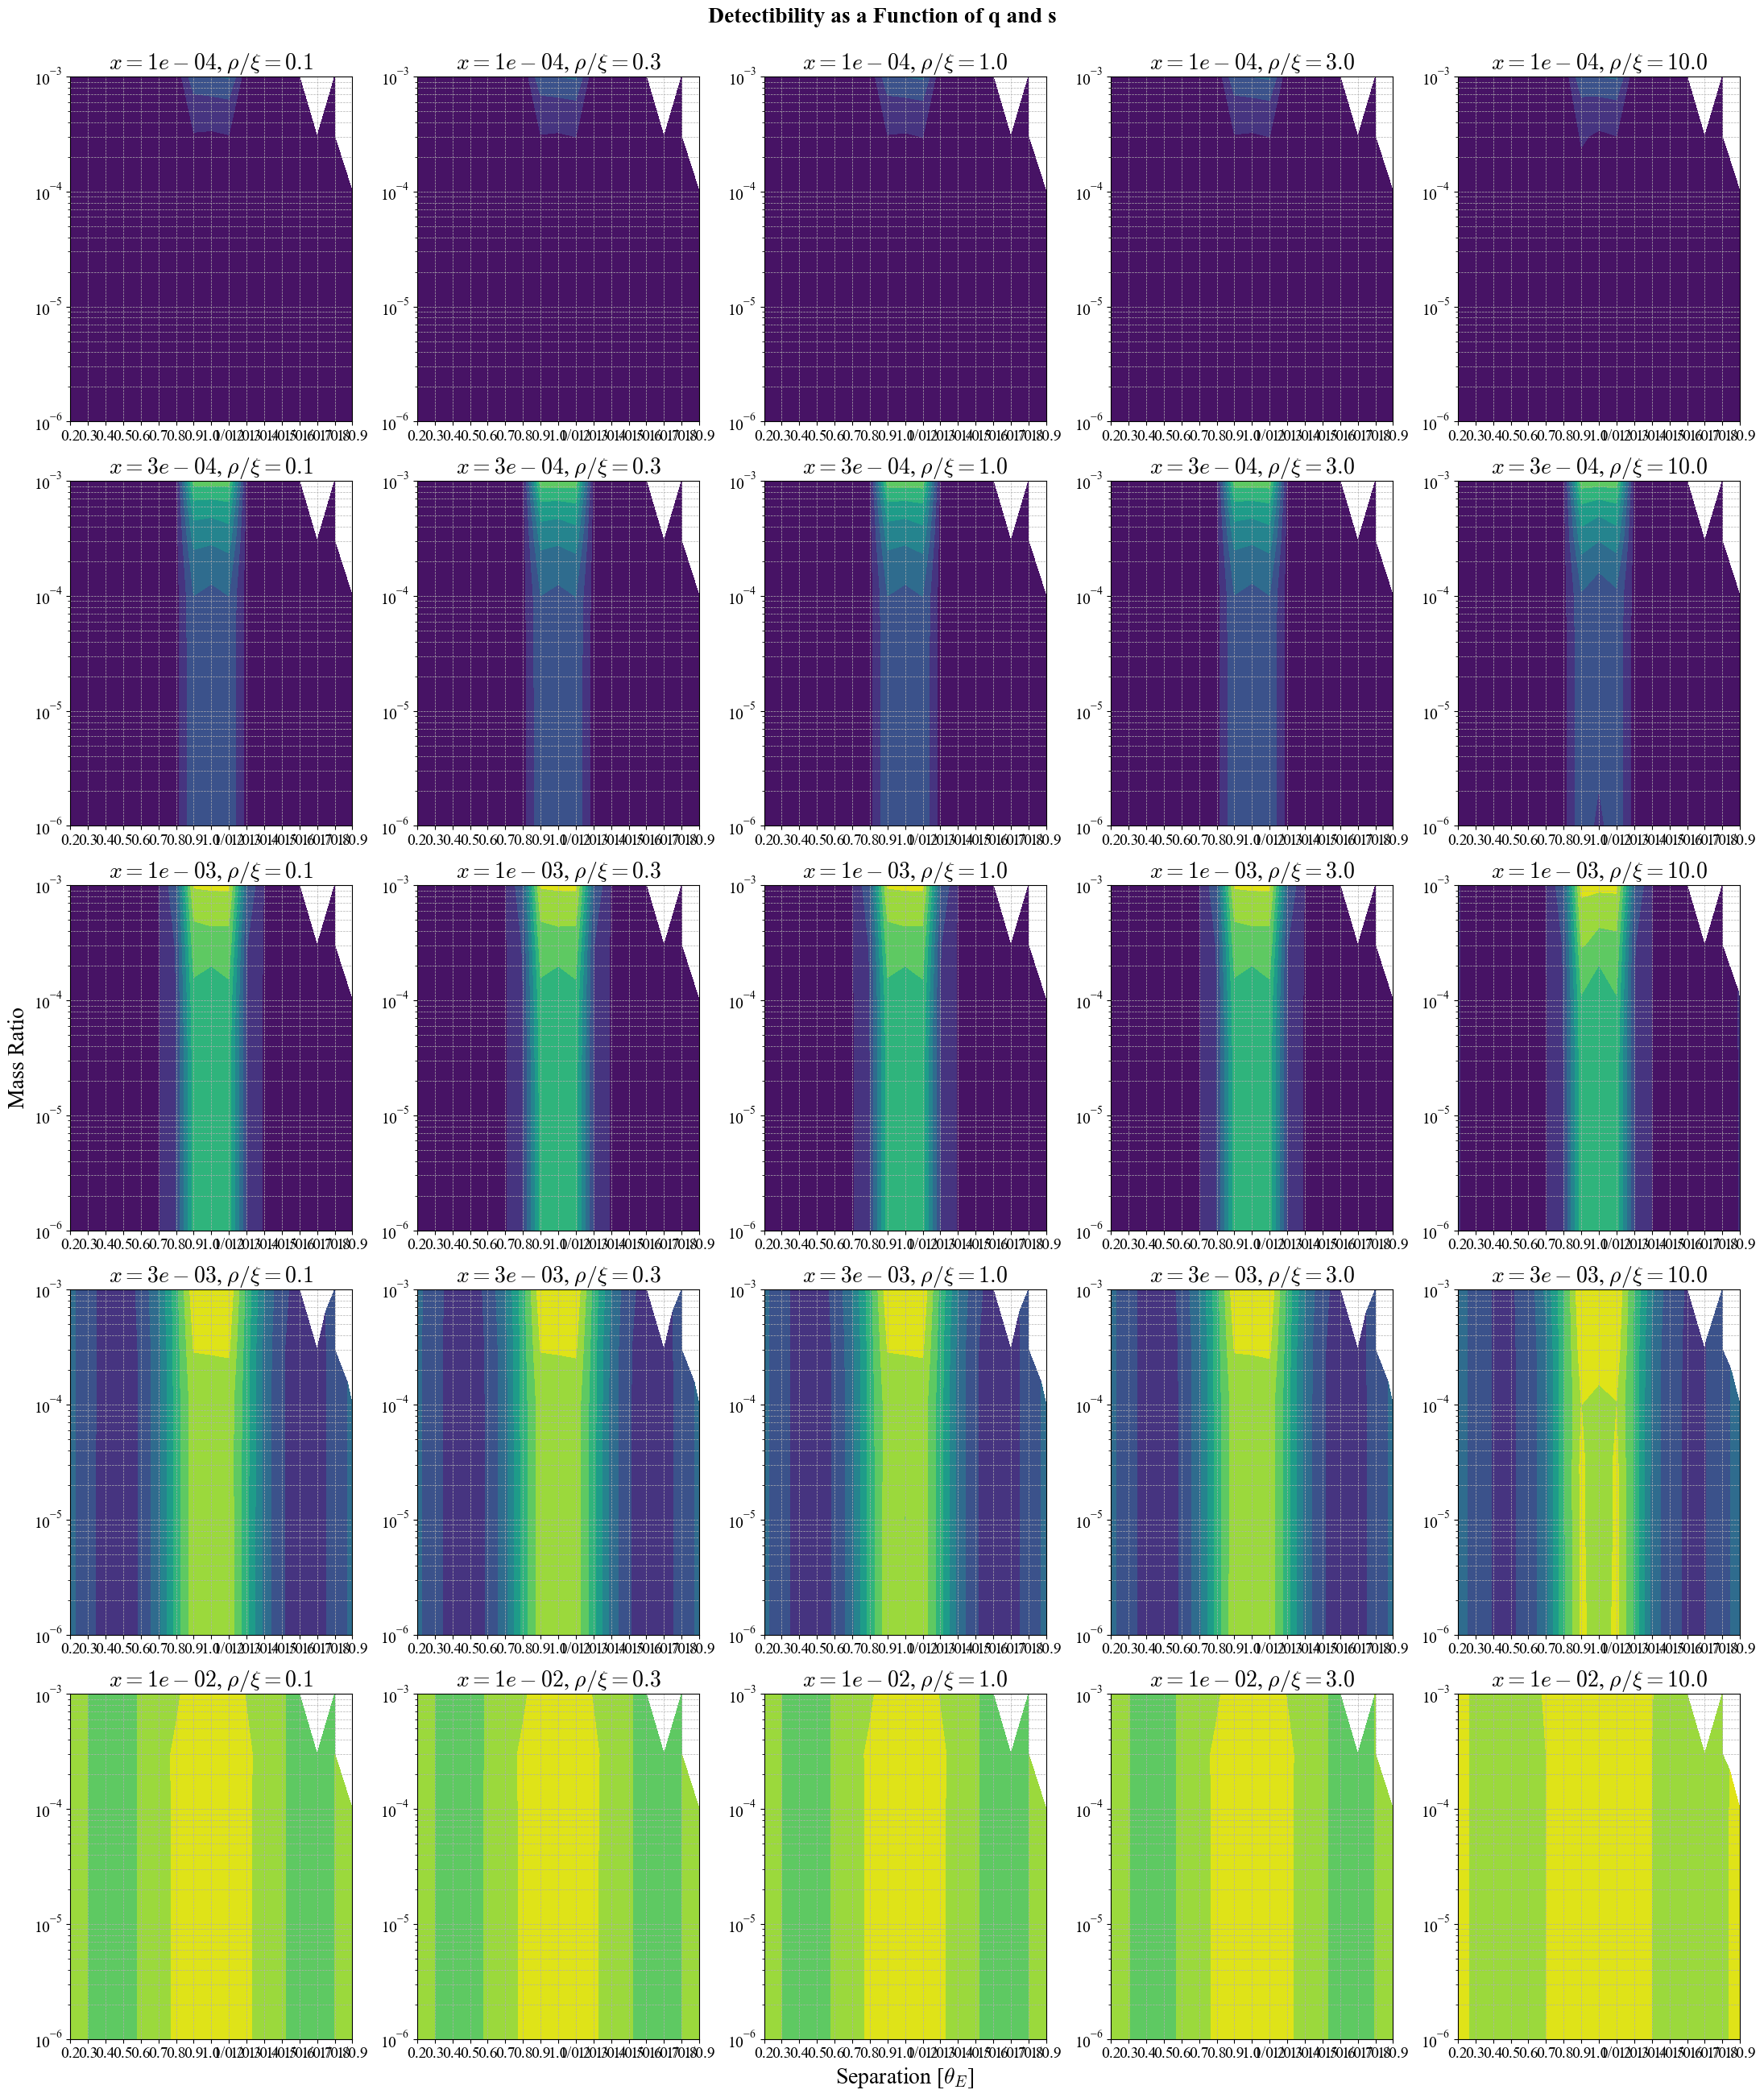

In [ ]:
fig = plt.figure(figsize=(22, 26))
fig.set_tight_layout(True)
axes = fig.subplots(5, 5)

fig.suptitle('Detectibility as a Function of q and s', y=1.0)

for i, threshold in enumerate([1.1e-04, 3.4e-04, 1.0e-03, 3.1e-03, 1.1e-02]):
    for j, multiplier in enumerate(multipliers):
        ax = axes[i, j]

        ax.set_title(f'$x={threshold:.0e}$, $\\rho/\\xi={multiplier}$')

        df_subset = df_list[j]

        # Fixing holes in data
        empty_arr = ['1/0.2', 3e-4] + [np.nan] * 102
        df_subset = pd.concat([df_subset, pd.DataFrame([empty_arr], columns=df_subset.columns, index=[116.5])], ignore_index=False)

        empty_arr = ['1/0.2', 1e-3] + [np.nan] * 102
        df_subset = pd.concat([df_subset, pd.DataFrame([empty_arr], columns=df_subset.columns, index=[117.5])], ignore_index=False)
        df_subset = df_subset.sort_index().reset_index(drop=True)

        empty_arr = ['1/0.4', 1e-3] + [np.nan] * 102
        df_subset = pd.concat([df_subset, pd.DataFrame([empty_arr], columns=df_subset.columns, index=[103.5])], ignore_index=False)

        df_subset = df_subset.sort_index().reset_index(drop=True)

        # ax.imshow(np.array(df_subset[f'{threshold:.1e}']).reshape((17, 7)).T, extent=[
        #     ss_unique_1.min(), ss_unique_1.max(),
        #     qs_unique_1.min(), qs_unique_1.max()
        # ], aspect='auto', origin='lower', norm=plt.Normalize(vmin=0, vmax=1), cmap='viridis')

        ax.contourf(
            np.linspace(0, 1, 17),
            qs_unique_1,
            np.array(df_subset[f'{threshold:.1e}']).reshape((17, 7)).T,
            levels=np.linspace(0, 1, 11),
            cmap='viridis',
            vmin=0, vmax=1
        )

        # ax.set_xscale('log')
        ax.set_yscale('log')
        ax.grid(True, which='both', linestyle='--', linewidth=0.5)
        ax.set_xticks(np.linspace(0, 1, 17))
        ax.set_xticklabels(ss_str_unique_1)

axes[-1, 2].set_xlabel('Separation [$\\theta_E$]')
axes[2, 0].set_ylabel('Mass Ratio')

# axes[1, -1].legend(bbox_to_anchor=(1.1, 1.05), loc='upper left', title='Thresholds')

plt.show()

In [97]:
df_subset = df_list[0]

# Fixing holes in data
empty_arr = ['1/0.2', 3e-4] + [np.nan] * 102
df_subset = pd.concat([df_subset, pd.DataFrame([empty_arr], columns=df_subset.columns, index=[116.5])], ignore_index=False)

empty_arr = ['1/0.2', 1e-3] + [np.nan] * 102
df_subset = pd.concat([df_subset, pd.DataFrame([empty_arr], columns=df_subset.columns, index=[117.5])], ignore_index=False)
df_subset = df_subset.sort_index().reset_index(drop=True)

empty_arr = ['1/0.4', 1e-3] + [np.nan] * 102
df_subset = pd.concat([df_subset, pd.DataFrame([empty_arr], columns=df_subset.columns, index=[103.5])], ignore_index=False)

df_subset = df_subset.sort_index().reset_index(drop=True)

for i in range(len(df_subset)):
    print(df_subset['s'][i], df_subset['q'][i])

print(np.array(df_subset['s']).reshape((17, 7)).T)
print(np.array(df_subset['q']).reshape((17, 7)).T)

0.2 1e-06
0.2 3e-06
0.2 1e-05
0.2 3e-05
0.2 0.0001
0.2 0.0003
0.2 0.001
0.3 1e-06
0.3 3e-06
0.3 1e-05
0.3 3e-05
0.3 0.0001
0.3 0.0003
0.3 0.001
0.4 1e-06
0.4 3e-06
0.4 1e-05
0.4 3e-05
0.4 0.0001
0.4 0.0003
0.4 0.001
0.5 1e-06
0.5 3e-06
0.5 1e-05
0.5 3e-05
0.5 0.0001
0.5 0.0003
0.5 0.001
0.6 1e-06
0.6 3e-06
0.6 1e-05
0.6 3e-05
0.6 0.0001
0.6 0.0003
0.6 0.001
0.7 1e-06
0.7 3e-06
0.7 1e-05
0.7 3e-05
0.7 0.0001
0.7 0.0003
0.7 0.001
0.8 1e-06
0.8 3e-06
0.8 1e-05
0.8 3e-05
0.8 0.0001
0.8 0.0003
0.8 0.001
0.9 1e-06
0.9 3e-06
0.9 1e-05
0.9 3e-05
0.9 0.0001
0.9 0.0003
0.9 0.001
1.0 1e-06
1.0 3e-06
1.0 1e-05
1.0 3e-05
1.0 0.0001
1.0 0.0003
1.0 0.001
1/0.9 1e-06
1/0.9 3e-06
1/0.9 1e-05
1/0.9 3e-05
1/0.9 0.0001
1/0.9 0.0003
1/0.9 0.001
1/0.8 1e-06
1/0.8 3e-06
1/0.8 1e-05
1/0.8 3e-05
1/0.8 0.0001
1/0.8 0.0003
1/0.8 0.001
1/0.7 1e-06
1/0.7 3e-06
1/0.7 1e-05
1/0.7 3e-05
1/0.7 0.0001
1/0.7 0.0003
1/0.7 0.001
1/0.6 1e-06
1/0.6 3e-06
1/0.6 1e-05
1/0.6 3e-05
1/0.6 0.0001
1/0.6 0.0003
1/0.6 0.001
1/0.5 1e

In [53]:
df_list[0].columns

Index(['s', 'q', 'source_radius', 'LD_coeff', '1.0e-08', '1.2e-08', '1.5e-08',
       '1.7e-08', '2.1e-08', '2.5e-08',
       ...
       '1.9e-01', '2.3e-01', '2.7e-01', '3.3e-01', '3.9e-01', '4.8e-01',
       '5.7e-01', '6.9e-01', '8.3e-01', '1.0e+00'],
      dtype='object', length=104)

In [44]:
binary_directory = './Unity/Simulations/Binary_Collection'
single_directory = './Unity/Simulations/Single_Collection'

q = 1e-3
s = 1/0.4

single_file = f'../../{single_directory}/Single_Collection_{q:.0e}/single_{q:.0e}_{1/(s):.2e}.pkl'
single_sim = IRSC.caustic_reader(single_file)

binary_file = f'../../{binary_directory}/Binary_Collection_{q:.0e}/binary_{q:.0e}_{s:.2e}.pkl'
binary_sim = IRSC.caustic_reader(binary_file)

print(single_sim.magnifications.shape)
print(binary_sim.magnifications.shape)

(4691, 4691)
(4690, 4690)


In [45]:
single_file = f'../../{single_directory}/single_{q:.0e}_{1/(s):.2e}.pkl'
single_sim = IRSC.caustic_reader(single_file)
print(single_sim.magnifications.shape)

FileNotFoundError: [Errno 2] No such file or directory: '../.././Unity/Simulations/Single_Collection/single_1e-03_4.00e-01.pkl'

In [121]:
np.array(df_list[0].columns[4:], dtype=float).tolist()

[1e-08,
 1.2e-08,
 1.5e-08,
 1.7e-08,
 2.1e-08,
 2.5e-08,
 3.1e-08,
 3.7e-08,
 4.4e-08,
 5.3e-08,
 6.4e-08,
 7.7e-08,
 9.3e-08,
 1.1e-07,
 1.4e-07,
 1.6e-07,
 2e-07,
 2.4e-07,
 2.8e-07,
 3.4e-07,
 4.1e-07,
 5e-07,
 6e-07,
 7.2e-07,
 8.7e-07,
 1e-06,
 1.3e-06,
 1.5e-06,
 1.8e-06,
 2.2e-06,
 2.7e-06,
 3.2e-06,
 3.9e-06,
 4.6e-06,
 5.6e-06,
 6.7e-06,
 8.1e-06,
 9.8e-06,
 1.2e-05,
 1.4e-05,
 1.7e-05,
 2.1e-05,
 2.5e-05,
 3e-05,
 3.6e-05,
 4.3e-05,
 5.2e-05,
 6.3e-05,
 7.6e-05,
 9.1e-05,
 0.00011,
 0.00013,
 0.00016,
 0.00019,
 0.00023,
 0.00028,
 0.00034,
 0.0004,
 0.00049,
 0.00059,
 0.00071,
 0.00085,
 0.001,
 0.0012,
 0.0015,
 0.0018,
 0.0022,
 0.0026,
 0.0031,
 0.0038,
 0.0045,
 0.0055,
 0.0066,
 0.0079,
 0.0095,
 0.011,
 0.014,
 0.017,
 0.02,
 0.024,
 0.029,
 0.035,
 0.042,
 0.051,
 0.061,
 0.074,
 0.089,
 0.11,
 0.13,
 0.16,
 0.19,
 0.23,
 0.27,
 0.33,
 0.39,
 0.48,
 0.57,
 0.69,
 0.83,
 1.0]